# Study 08 — What happens if the estimate forgets old data?

Study 07 showed a problem with using a player's entire history to estimate current ability.

If a player genuinely improves, old observations continue to receive the same weight as recent ones. The estimate can therefore remain stable and precise while becoming slow to reflect the player's current level.

This study changes one thing only.

The player's true frame-win probability will again jump from 58% to 64%, but instead of estimating ability from every frame observed so far, we will estimate it from only the most recent **250 frames**.

The question is:

> What do we gain — and what do we lose — by deliberately forgetting older results?

Frames remain independent. There is still no momentum, parameter uncertainty, Bayesian updating, recency weighting, or optimisation of the window size.

The purpose is simply to establish the basic trade-off:

**A shorter memory should respond more quickly to genuine change, but it should also produce a less stable estimate.**

In [1]:
import numpy as np

# Keep the same ability change as Study 07.
p_before = 0.58
p_after = 0.64

# Observe 1,000 frames before the change and 1,000 after it.
n_before = 1_000
n_after = 1_000

# Estimate current ability using only the most recent 250 frames.
window_size = 250

## Expected behaviour of a 250-frame window

Before adding random sampling variation, we can work out what the rolling estimate should do on average.

At the moment the player's ability changes, the 250-frame window still contains only old 58% frames.

As new 64% frames arrive, they gradually replace those older observations.

For the first 250 post-change frames, the expected rolling estimate is therefore a mixture of:

- old frames generated at 58%;
- new frames generated at 64%.

After 250 new frames, every observation in the window comes from the new 64% level. At that point the old history has been completely forgotten.

This gives us a useful benchmark: if the rolling window works as intended, it should adapt fully within **250 frames**, rather than remaining permanently diluted by the player's earlier career.

In [2]:
# Number of new 64% frames that have entered the rolling window.
post_change_frames = np.arange(window_size + 1)

# During the transition, old 58% frames are gradually replaced by new 64% frames.
expected_rolling = (
    (window_size - post_change_frames) * p_before
    + post_change_frames * p_after
) / window_size

expected_rolling[:5], expected_rolling[-1]

(array([0.58   , 0.58024, 0.58048, 0.58072, 0.58096]), np.float64(0.64))

In [3]:
# Check how quickly the expected estimate moves toward the new 64% level.
checkpoints = np.array([0, 50, 100, 125, 200, 250])

expected_at_checkpoints = (
    (window_size - checkpoints) * p_before
    + checkpoints * p_after
) / window_size

list(zip(checkpoints, expected_at_checkpoints))

[(np.int64(0), np.float64(0.58)),
 (np.int64(50), np.float64(0.592)),
 (np.int64(100), np.float64(0.604)),
 (np.int64(125), np.float64(0.61)),
 (np.int64(200), np.float64(0.628)),
 (np.int64(250), np.float64(0.64))]

## The responsiveness gain

The rolling window reacts much faster than the career-to-date estimate from Study 07.

Because the window contains only 250 frames, every new 64% observation pushes one old 58% observation out.

The expected estimate therefore moves steadily toward the player's new level:

- after 50 new frames: 59.2%;
- after 100: 60.4%;
- after 125: 61.0%;
- after 200: 62.8%;
- after 250: 64.0%.

After 250 post-change frames, none of the old 58% observations remain in the estimator.

This is the main benefit of forgetting old data: **the estimate can stop being stale much sooner.**

But this has not yet shown the cost. A 250-frame estimate is based on far less information than a career-to-date estimate, so we should expect it to move around more from random sampling variation.

In [4]:
# Use a fixed seed so this example is reproducible.
rng = np.random.default_rng(8)

# Generate 1,000 frames at the old level, followed by 1,000 at the new level.
frames_before = rng.binomial(1, p_before, size=n_before)
frames_after = rng.binomial(1, p_after, size=n_after)

frames = np.concatenate([frames_before, frames_after])

frames.shape, frames_before.mean(), frames_after.mean()

((2000,), np.float64(0.61), np.float64(0.644))

### Reminder: what the binomial draw represents

For each frame, we treat the outcome as a simple win or loss.

A binomial draw with `n = 1` is therefore just a Bernoulli trial:

- `1` means the player wins the frame;
- `0` means the player loses the frame.

For example, `rng.binomial(1, 0.58)` generates one frame in which the player has a 58% chance of winning.

Repeating that process many times gives us a simulated sequence of frame results. The realised win percentage will usually be close to the underlying probability, but not exactly equal to it because of random sampling variation.

In [5]:
# Calculate the win rate in each complete 250-frame window.
rolling_estimate = np.convolve(
    frames,
    np.ones(window_size) / window_size,
    mode="valid",
)

# The first estimate uses frames 1–250.
# Each later value drops the oldest frame and adds the newest one.
rolling_estimate.shape, rolling_estimate[:5], rolling_estimate[-5:]

((1751,),
 array([0.588, 0.588, 0.592, 0.588, 0.588]),
 array([0.644, 0.64 , 0.636, 0.64 , 0.636]))

In [6]:
# Frame number corresponding to the end of each 250-frame window.
rolling_frame = np.arange(window_size, len(frames) + 1)

# Inspect the estimates around the point where ability changes after frame 1,000.
mask = (rolling_frame >= 990) & (rolling_frame <= 1010)

list(zip(rolling_frame[mask], rolling_estimate[mask]))

[(np.int64(990), np.float64(0.6000000000000001)),
 (np.int64(991), np.float64(0.6000000000000001)),
 (np.int64(992), np.float64(0.5960000000000001)),
 (np.int64(993), np.float64(0.6000000000000001)),
 (np.int64(994), np.float64(0.6000000000000001)),
 (np.int64(995), np.float64(0.6000000000000001)),
 (np.int64(996), np.float64(0.6000000000000001)),
 (np.int64(997), np.float64(0.6000000000000001)),
 (np.int64(998), np.float64(0.6000000000000001)),
 (np.int64(999), np.float64(0.6040000000000001)),
 (np.int64(1000), np.float64(0.6040000000000001)),
 (np.int64(1001), np.float64(0.6080000000000001)),
 (np.int64(1002), np.float64(0.6120000000000001)),
 (np.int64(1003), np.float64(0.6120000000000001)),
 (np.int64(1004), np.float64(0.6160000000000001)),
 (np.int64(1005), np.float64(0.6120000000000001)),
 (np.int64(1006), np.float64(0.6120000000000001)),
 (np.int64(1007), np.float64(0.6120000000000001)),
 (np.int64(1008), np.float64(0.6080000000000001)),
 (np.int64(1009), np.float64(0.6080000000

In [7]:
# Look at the realised rolling estimate as new 64% frames enter the window.
checkpoint_frames = np.array([1_000, 1_050, 1_100, 1_125, 1_200, 1_250])

checkpoint_estimates = [
    rolling_estimate[frame - window_size]
    for frame in checkpoint_frames
]

list(zip(checkpoint_frames, checkpoint_estimates))

[(np.int64(1000), np.float64(0.6040000000000001)),
 (np.int64(1050), np.float64(0.6320000000000001)),
 (np.int64(1100), np.float64(0.676)),
 (np.int64(1125), np.float64(0.7000000000000001)),
 (np.int64(1200), np.float64(0.6960000000000001)),
 (np.int64(1250), np.float64(0.6880000000000002))]

## Responsiveness does not mean accuracy at every moment

The simulated rolling estimate reacts quickly to the improvement, but its path is much less orderly than the expected-value calculation.

At frame 1,000, just before the change, the 250-frame estimate happens to be 60.4% even though the player's true ability is 58%.

After the improvement it rises rapidly:

- frame 1,050: 63.2%;
- frame 1,100: 67.6%;
- frame 1,125: 70.0%;
- frame 1,200: 69.6%;
- frame 1,250: 68.8%.

By frame 1,250, all 250 observations in the window come from the new 64% level. The estimator is therefore no longer stale at all.

But it still does not equal 64%.

The rolling window has solved one problem by creating a trade-off: **old information disappears quickly, but with only 250 observations the estimate is more exposed to random variation.**

In this particular simulation it temporarily overshoots the player's true ability by several percentage points.

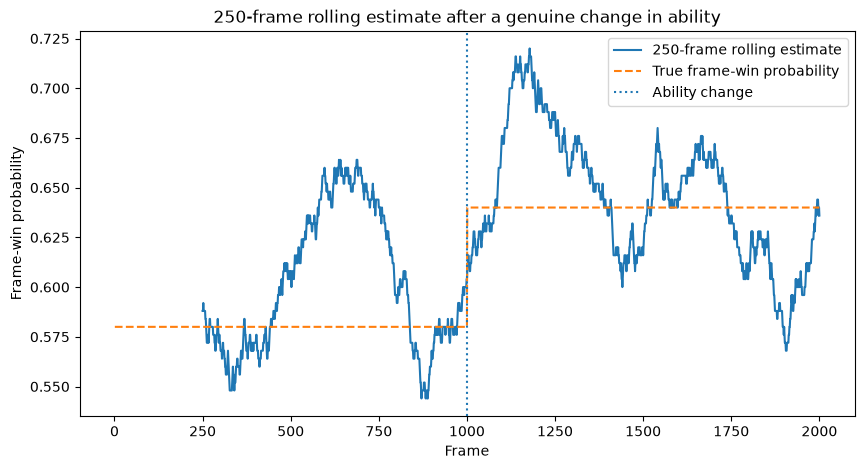

In [8]:
import matplotlib.pyplot as plt

# True frame-win probability across the full 2,000-frame sequence.
true_probability = np.concatenate([
    np.full(n_before, p_before),
    np.full(n_after, p_after),
])

plt.figure(figsize=(10, 5))

plt.plot(
    rolling_frame,
    rolling_estimate,
    label="250-frame rolling estimate",
)

plt.plot(
    np.arange(1, len(frames) + 1),
    true_probability,
    linestyle="--",
    label="True frame-win probability",
)

# Mark the frame after which the player's underlying ability changes.
plt.axvline(
    n_before,
    linestyle=":",
    label="Ability change",
)

plt.xlabel("Frame")
plt.ylabel("Frame-win probability")
plt.title("250-frame rolling estimate after a genuine change in ability")
plt.legend()
plt.show()

## What the rolling estimate looks like in practice

The chart makes both sides of the trade-off visible.

Before the player's ability changes, the true frame-win probability remains fixed at 58%, yet the 250-frame estimate moves noticeably above and below that level.

After frame 1,000, the estimator responds quickly to the genuine improvement. Old 58% observations are progressively removed from the window and replaced by new 64% observations.

But the response is noisy rather than smooth. The estimate initially overshoots the new level and continues to fluctuate around it even after all pre-change frames have disappeared from the window.

Nothing in the model is causing the player's ability to move during these fluctuations. They arise purely because each estimate is based on a sample of only 250 frames.

So forgetting old data has done what we wanted: **it has made the estimate more responsive to current ability.**

The price is equally clear: **the estimate is now less stable.**

## How variable should a 250-frame estimate be?

The chart shows the rolling estimate moving around even when the player's true ability is unchanged. We can put a number on how much random movement we should normally expect.

### What is standard deviation?

Standard deviation is a measure of **spread**.

Imagine we repeatedly observed different sets of 250 frames from a player whose true ability never changed. Each set would produce a slightly different observed win percentage simply because of chance.

Some samples would contain more wins than expected, some fewer.

The standard deviation tells us the typical scale of that variation around the true value. A larger standard deviation means the estimates tend to be more spread out; a smaller one means they tend to stay closer together.

For an estimated win proportion based on independent win/loss observations, the standard deviation is:

$$
\sqrt{\frac{p(1-p)}{n}}
$$

where:

- `p` is the player's true frame-win probability;
- `n` is the number of frames used in the estimate.

Because this is specifically the standard deviation of an **estimate across repeated samples**, it is also commonly called the **standard error**.

Here, `n = 250`.

We can calculate the expected sampling variation at both the 58% and 64% ability levels used in this study.

In [9]:
# Sampling standard deviation of a 250-frame win-rate estimate.
sd_before = np.sqrt(p_before * (1 - p_before) / window_size)
sd_after = np.sqrt(p_after * (1 - p_after) / window_size)

sd_before, sd_after

(np.float64(0.031215380824202676), np.float64(0.030357865537616442))

### What does that mean in practice?

At both ability levels, the standard deviation of a 250-frame estimate is about **3 percentage points**.

That is fairly large relative to the six-percentage-point improvement we are trying to detect.

So even if the player's true ability stays fixed at 64%, repeated 250-frame samples will not all produce estimates close to exactly 64%. Random samples several percentage points above or below the true value are entirely plausible.

This helps explain the simulated path.

At frame 1,250 the rolling estimate was 68.8%, even though every frame in that window came from a player whose true frame-win probability was 64%.

The rolling estimator had successfully forgotten the stale 58% history. Its remaining error came from a different source: **sampling variation within the smaller 250-frame sample.**

### Turning the standard deviation into an intuitive range

A standard deviation of about 3 percentage points is easier to understand if we treat it as a **distance from the true value**.

Suppose the player's true frame-win probability is 64%.

If the standard deviation of a 250-frame estimate is about 3 percentage points, then:

- **one standard deviation below** 64% is about 61%;
- **one standard deviation above** 64% is about 67%.

So being **within one standard deviation** means being roughly between 61% and 67%.

Two standard deviations simply means twice that distance:

- two standard deviations below 64% is about 58%;
- two standard deviations above 64% is about 70%.

So being **within two standard deviations** means being roughly between 58% and 70%.

Why are these ranges useful?

If we repeatedly took different 250-frame samples from a player whose true ability remained fixed at 64%, the resulting estimates would form an approximately bell-shaped distribution around 64%.

For a bell-shaped distribution:

- about 68% of estimates fall within one standard deviation of the centre;
- about 95% fall within two standard deviations.

These are not hard boundaries. An estimate outside them is still possible. They describe how much random variation we should normally expect from repeated samples.

This means that even when the player's true ability is a completely unchanged 64%, an observed 250-frame estimate can move several percentage points either side of 64% simply by chance.

That is the price of using a relatively short window: **we gain responsiveness, but individual estimates become less precise.**

In [10]:
# Convert the standard deviation into exact ranges around the new 64% ability level.
one_sd_range = (
    p_after - sd_after,
    p_after + sd_after,
)

two_sd_range = (
    p_after - 2 * sd_after,
    p_after + 2 * sd_after,
)

one_sd_range, two_sd_range

((np.float64(0.6096421344623836), np.float64(0.6703578655376164)),
 (np.float64(0.5792842689247671), np.float64(0.7007157310752329)))

### Relating the range back to our simulation

For a player whose true frame-win probability is 64%, our 250-frame estimator has:

- a one-standard-deviation range of about 61.0% to 67.0%;
- a two-standard-deviation range of about 57.9% to 70.1%.

Earlier, the rolling estimate reached 68.8% at frame 1,250.

That is outside the one-standard-deviation range, but still comfortably inside the two-standard-deviation range.

The estimate also briefly reached 70.0%, which is close to the upper edge of the two-standard-deviation range.

So the apparently dramatic overshoot in our simulated path is not evidence that the player's ability has changed again. It is consistent with the amount of sampling variation we should expect from an estimate based on only 250 frames.

One caution: successive rolling estimates overlap heavily because neighbouring windows share 249 of their 250 frames. We should therefore not treat the sequence of rolling estimates as a set of independent samples.

The standard-deviation calculation is telling us about the variability we would expect from repeated 250-frame samples under a fixed true ability.

In [11]:
# Simulate many separate 250-frame samples from a player who is truly 64%.
n_samples = 10_000

sample_wins = rng.binomial(
    window_size,
    p_after,
    size=n_samples,
)

sample_estimates = sample_wins / window_size

sample_estimates.mean(), sample_estimates.std()

(np.float64(0.6398296), np.float64(0.030525631260303214))

### The theoretical variability matches simulation

To check the calculation, we generated 10,000 independent samples of 250 frames from a player whose true frame-win probability remained fixed at 64%.

Across those samples:

- the average estimated win probability was 63.98%;
- the observed standard deviation was about 3.05 percentage points.

Our theoretical calculation predicted a standard deviation of about 3.04 percentage points.

The two results are almost identical.

This confirms that the movement in a 250-frame estimate does not require any further change in the player's ability. Even under a completely fixed 64% probability, estimates based on only 250 frames naturally move around by several percentage points.

The rolling window therefore creates a genuine trade-off:

**it forgets stale information quickly, but the smaller amount of retained data makes its estimate noisier.**

In [12]:
# Check how often independent 250-frame estimates fall within
# one and two theoretical standard deviations of the true 64% value.
within_one_sd = np.mean(
    (sample_estimates >= one_sd_range[0])
    & (sample_estimates <= one_sd_range[1])
)

within_two_sd = np.mean(
    (sample_estimates >= two_sd_range[0])
    & (sample_estimates <= two_sd_range[1])
)

within_one_sd, within_two_sd

(np.float64(0.6773), np.float64(0.9568))

### The usual standard-deviation rule appears in the simulation

The repeated-sample simulation gives:

- 67.73% of estimates within one standard deviation of the true 64% level;
- 95.68% within two standard deviations.

Those are very close to the familiar approximate 68% and 95% rules for a bell-shaped distribution.

The match is not expected to be exact. A 250-frame win rate can only take discrete values such as 63.6%, 64.0%, 64.4%, and so on, because each additional win changes the estimate by 1/250 = 0.4 percentage points.

But the agreement is close enough to confirm the practical interpretation:

A 250-frame estimate will often be a few percentage points away from the player's true ability even when that ability is completely stable.

That variability is not a defect in the calculation. It is the unavoidable consequence of estimating a probability from a limited sample.

In [13]:
# Expected career-to-date estimate from Study 07 after selected
# numbers of post-change frames.
comparison_points = np.array([50, 100, 125, 200, 250])

career_expected = (
    n_before * p_before
    + comparison_points * p_after
) / (n_before + comparison_points)

rolling_expected = (
    (window_size - comparison_points) * p_before
    + comparison_points * p_after
) / window_size

list(zip(comparison_points, career_expected, rolling_expected))

[(np.int64(50), np.float64(0.5828571428571429), np.float64(0.592)),
 (np.int64(100), np.float64(0.5854545454545454), np.float64(0.604)),
 (np.int64(125), np.float64(0.5866666666666667), np.float64(0.61)),
 (np.int64(200), np.float64(0.59), np.float64(0.628)),
 (np.int64(250), np.float64(0.592), np.float64(0.64))]

## Compared with keeping the whole career

The gain from forgetting old data becomes especially clear when we compare expected values with Study 07.

After the player's true frame-win probability rises from 58% to 64%:

- after 50 new frames, the career estimate is only 58.3%, while the rolling estimate is 59.2%;
- after 100, the career estimate is 58.5%, while the rolling estimate is 60.4%;
- after 125, the career estimate is 58.7%, while the rolling estimate is 61.0%;
- after 200, the career estimate is 59.0%, while the rolling estimate is 62.8%;
- after 250, the career estimate is still only 59.2%, while the rolling estimate has reached 64.0%.

The reason is simple.

The career estimator keeps all 1,000 pre-change frames permanently. Even after 250 new frames, those old observations still make up 80% of its data.

The rolling estimator behaves differently. Every new frame pushes one old frame out of the 250-frame window. After 250 new frames, the old 58% period has disappeared from the estimate completely.

So the responsiveness gain is not mysterious: **the rolling estimator adapts because it deliberately throws information away.**

That solves the stale-history problem from Study 07 much faster.

But the earlier simulation showed the cost of doing so: once we restrict ourselves to 250 observations, random sampling variation becomes much more visible.

## Responsiveness versus stability at the same moment

We can now put the two effects together.

Consider the player at frame 1,250 — exactly 250 frames after the genuine improvement.

At this point:

- the 250-frame rolling window contains only post-change observations generated at 64%;
- the career-to-date estimator still contains all 1,000 old 58% frames as well as the 250 newer frames.

For one simulated career, either estimate might happen to be unusually high or low.

So instead of relying on one path, we can simulate many versions of exactly the same career and examine what each estimator looks like at frame 1,250.

This should expose the trade-off directly.

We expect the rolling estimator to be centred near the player's **current 64% ability**, but to be relatively spread out.

We expect the career estimator to be more tightly clustered, but centred well below 64% because it is still heavily influenced by stale history.

In other words, one estimator should be **more responsive but less stable**, while the other should be **more stable but more stale**.

In [14]:
# Simulate many possible careers observed at frame 1,250.
n_careers = 10_000
rng_compare = np.random.default_rng(808)

# Each career contains 1,000 old 58% frames and 250 new 64% frames.
old_wins = rng_compare.binomial(n_before, p_before, size=n_careers)
new_wins = rng_compare.binomial(window_size, p_after, size=n_careers)

# Career estimate keeps both periods; rolling estimate keeps only the newest 250 frames.
career_estimates_1250 = (old_wins + new_wins) / (n_before + window_size)
rolling_estimates_1250 = new_wins / window_size

(
    career_estimates_1250.mean(),
    career_estimates_1250.std(),
    rolling_estimates_1250.mean(),
    rolling_estimates_1250.std(),
)

(np.float64(0.5919272800000001),
 np.float64(0.013796761061988426),
 np.float64(0.6402932),
 np.float64(0.030038515838170184))

## The trade-off appears directly

Across 10,000 simulated careers observed at frame 1,250, the two estimators behave very differently.

The career-to-date estimator has:

- an average estimate of 59.19%;
- a standard deviation of about 1.38 percentage points.

The 250-frame rolling estimator has:

- an average estimate of 64.03%;
- a standard deviation of about 3.00 percentage points.

The career estimator is clearly more stable. Its estimates are much more tightly clustered because it uses 1,250 observations.

But that stability comes with a serious cost.

The player's current frame-win probability is 64%, yet the career estimator remains centred around only 59.2% because most of its observations come from the earlier 58% period.

The rolling estimator does the opposite.

By frame 1,250 it has completely discarded the old period, so its estimates are centred almost exactly on the player's current 64% ability.

But because it uses only 250 observations, those estimates are much more widely spread.

This is the central trade-off of the study:

**Keeping more history produces a more stable estimate of the past mixture. Forgetting history produces a less stable estimate that is much more responsive to the present.**

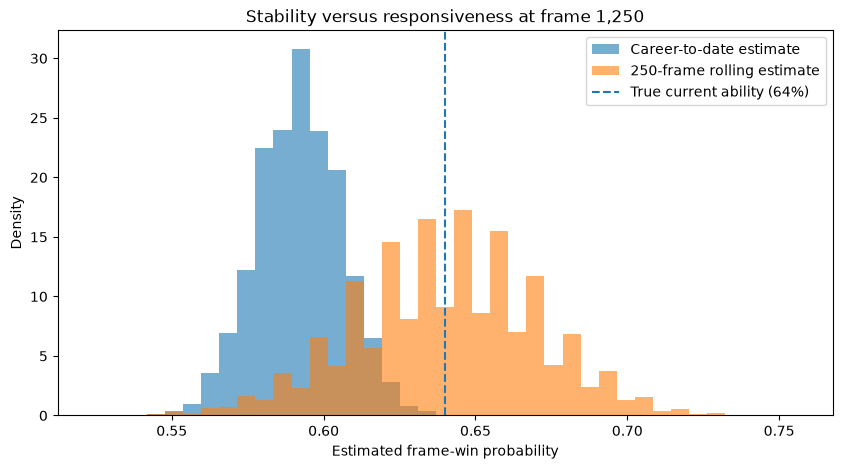

In [15]:
# Put both estimator distributions on the same scale.
combined_min = min(career_estimates_1250.min(), rolling_estimates_1250.min())
combined_max = max(career_estimates_1250.max(), rolling_estimates_1250.max())
bins = np.linspace(combined_min, combined_max, 40)

plt.figure(figsize=(10, 5))

plt.hist(
    career_estimates_1250,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Career-to-date estimate",
)

plt.hist(
    rolling_estimates_1250,
    bins=bins,
    density=True,
    alpha=0.6,
    label="250-frame rolling estimate",
)

# Mark the player's actual current ability.
plt.axvline(
    p_after,
    linestyle="--",
    label="True current ability (64%)",
)

plt.xlabel("Estimated frame-win probability")
plt.ylabel("Density")
plt.title("Stability versus responsiveness at frame 1,250")
plt.legend()
plt.show()

## Seeing the trade-off

The two distributions make the contrast very clear.

The career-to-date estimator is tightly concentrated. Across repeated careers, it produces estimates that are relatively stable.

But it is stable around the wrong target for the present.

At frame 1,250, the player's true current ability is 64%, yet the career estimator remains centred near 59.2% because the 1,000 older 58% frames still dominate its history.

The 250-frame rolling estimator is much more widely spread.

Individual estimates can land several percentage points above or below 64% simply because of sampling variation.

But the distribution itself is centred on the player's current ability.

So neither estimator is simply "better" in every sense.

The career estimator has lower variance but greater staleness after a genuine change.

The rolling estimator has less staleness but greater variance.

That is the basic price of forgetting old data:

**responsiveness is bought with instability.**

## Sanity check: what if ability never changes?

The rolling window only has an advantage because the player's underlying ability changed.

If the player stayed at 64% throughout, there would be no stale history to forget.

In that situation, both estimators should be centred on the same true 64% ability.

The difference should then be purely about stability:

- the career estimate uses more observations, so it should vary less;
- the 250-frame rolling estimate uses fewer observations, so it should vary more.

This is a useful sanity check because it shows that a rolling window is not automatically a better estimator.

Its advantage appears when older observations stop being representative of the present.

In [16]:
# Sanity check: simulate careers where ability is 64% for all 1,250 frames.
stable_wins_1250 = rng_compare.binomial(
    n_before + window_size,
    p_after,
    size=n_careers,
)

stable_wins_250 = rng_compare.binomial(
    window_size,
    p_after,
    size=n_careers,
)

stable_career_estimates = stable_wins_1250 / (n_before + window_size)
stable_rolling_estimates = stable_wins_250 / window_size

(
    stable_career_estimates.mean(),
    stable_career_estimates.std(),
    stable_rolling_estimates.mean(),
    stable_rolling_estimates.std(),
)

(np.float64(0.63995944),
 np.float64(0.013579493469433978),
 np.float64(0.6400208),
 np.float64(0.030320203946543643))

### When nothing changes, forgetting history only adds noise

The sanity check behaves exactly as expected.

When the player's true frame-win probability stays fixed at 64% for all 1,250 frames:

- the career-to-date estimator averages 64.00%;
- the 250-frame rolling estimator also averages 64.00%.

Neither estimator is stale because there has been no change in the underlying ability.

The difference is therefore entirely about sampling variation.

The 1,250-frame career estimate has a standard deviation of about 1.36 percentage points, while the 250-frame rolling estimate has a standard deviation of about 3.03 percentage points.

So if old observations remain representative of the present, throwing them away provides no benefit here. It simply reduces the effective sample size and makes the estimate noisier.

The rolling window becomes useful only when the past has stopped being a good description of the present.

## Conclusion

Study 07 showed that retaining a player's entire history can make an estimate slow to recognise genuine improvement.

Study 08 changed only one thing: instead of using every frame observed so far, the estimator kept only the most recent 250 frames.

That immediately changed the trade-off.

The rolling estimator adapted much faster because old 58% observations were progressively removed from the sample. After 250 post-change frames, the window contained only observations generated at the new 64% level.

In expected-value terms, the estimator had fully caught up.

But the smaller effective sample made the estimate much more variable.

Across repeated 250-frame samples from a genuinely 64% player, the standard deviation of the estimated win probability was about 3 percentage points. Individual estimates could therefore sit several points above or below the true value even when the player's ability was perfectly stable.

The comparison at frame 1,250 made the trade-off especially clear:

- the career-to-date estimator was tightly clustered around about 59.2%;
- the 250-frame rolling estimator was much more widely spread, but centred around 64%.

The career estimator was more stable, but stale.

The rolling estimator was more responsive, but noisier.

A final sanity check showed that if the player's ability never changes, the rolling window provides no special advantage. Both estimators remain centred on the truth, while the larger career sample is simply more stable.

So forgetting history is not automatically better.

It becomes useful when older observations stop being representative of the present.

The core conclusion is:

> **There is no free way to make an estimate more responsive. Forgetting old data reduces staleness, but the smaller sample increases uncertainty.**

This study deliberately stops there.

It does not ask whether 250 frames is the best window, compare different window lengths, introduce gradual weighting, or try to optimise the balance between responsiveness and stability.

Those are separate questions.